# Twelve rate-of-change lines walk into a chart... 🔀
### Special K — Martin Pring's "reduced-whipsaw" indicator, sold as a caller of **major cyclic turns**

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Flags_major_cyclic_turns%3F: Busted](https://img.shields.io/badge/Flags_major_cyclic_turns%3F-Busted-8b949e?style=flat-square)

Martin Pring already had a momentum oscillator with his name and marketing behind it — the [Know Sure Thing](../../426-know-sure-thing/) — and then built a bigger one: **Special K** sums **twelve** smoothed rate-of-change lines instead of four, blending two-week swings with two-year cycles into a single line. Cross that line against its own signal average and, the story goes, you get a rare, clean flag for the market's **big** turns — bear-market bottoms, bull-market tops — filtered of all the whipsaw a simpler tool would suffer.

That's a specific, falsifiable claim: crossovers should precede *abnormal* forward returns. We test it on three different real tapes, at three different horizons, against a random-timing control, and as an actual tradeable rule.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the three-tape cross-check? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Pring's canonical daily periods (10, 15, 20, 30, 50, 65, 75, 100, 195, 265, 390, 530), weighted 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, signal SMA 100 (StockCharts ChartSchool). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from special_k import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY, GSPC = data.load_real()
    WK = data.weekly_from_daily(SPY)
    CROSS_SPY = st.crossover_dates(SPY)
    CROSS_GSPC = st.crossover_dates(GSPC)
else:
    SPY = GSPC = WK = CROSS_SPY = CROSS_GSPC = None
print("real cache present:", HAVE_REAL, "| SPY bars:", (0 if SPY is None else len(SPY)))

# frozen headline numbers (mirror of docs/results.md)
R = {'spy_start': '1993-01-29', 'gspc_start': '1962-01-02', 'asof': '2026-06-30', 'n_spy': 8411, 'n_gspc': 16231, 'n_wk': 1745, 'roc_periods': (10, 15, 20, 30, 50, 65, 75, 100, 195, 265, 390, 530), 'weights': (1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4), 'signal_n': 100, 'fp_spy': 'cedd4a6ddffe', 'fp_gspc': '966bf2f599bf', 'spy_bull': 51, 'spy_bear': 51, 'gspc_bull': 114, 'gspc_bear': 113, 'wk_bull': 55, 'wk_bear': 55, 'event': {21: (0.017, 0.044, -0.9, -0.002, 0.047, -1.26), 63: (0.024, 0.051, -1.33, 0.033, 0.045, -0.57), 126: (0.025, 0.066, -2.37, 0.042, 0.039, 0.18)}, 'placebo_bull_obs': 3.18, 'placebo_bull_mean': 5.06, 'placebo_bull_p': 0.8838, 'placebo_bear_obs': 5.28, 'placebo_bear_mean': 5.06, 'placebo_bear_p': 0.5502, 'gspc_bull_window': 0.03, 'gspc_bull_base': 0.027, 'gspc_bull_t': 0.23, 'gspc_bear_window': 0.032, 'gspc_bear_base': 0.023, 'gspc_bear_t': 0.6, 'sk_sharpe': 0.457, 'sk_cagr': 4.11, 'sk_maxdd': -27.7, 'sk_hac': 3.04, 'sk_expo': 0.47, 'sk_trades': 103, 'sk_turn': 3.1, 'bah_sharpe': 0.646, 'bah_cagr': 10.81, 'bah_maxdd': -55.2, 'bah_hac': 4.35, 'sma_sharpe': 0.731, 'sma_cagr': 8.38, 'sma_maxdd': -28.3, 'sma_hac': 4.54, 'sma_trades': 215, 'perm_obs': 0.46, 'perm_p': 0.0038, 'spread_spy': -7.48, 'spread_spy_t': -3.15, 'spread_gspc': -4.47, 'spread_gspc_t': -2.81, 'spread_wk': -7.8, 'spread_wk_t': -3.51, 'cost_sweep': [(0.0, 0.46, 0.646), (1.0, 0.457, 0.646), (2.0, 0.454, 0.646), (5.0, 0.444, 0.646)], 'param_sweep': [(0.7, 0.336, 2.08, 2.86, 161), (1.0, 0.457, 3.04, 4.11, 103), (1.3, 0.643, 4.19, 5.65, 69)], 'gspc_sk_sharpe': 0.445, 'gspc_sk_hac': 3.76, 'gspc_bah_sharpe': 0.522, 'gspc_bah_hac': 4.45, 'wk_sk_sharpe': 0.4, 'wk_sk_hac': 2.53, 'wk_bah_sharpe': 0.683, 'wk_bah_hac': 4.41, 'kst_sharpe': 0.445, 'kst_trades': 458, 'kst_spread': -7.16, 'kst_spread_t': -3.31, 'syn_null_t': -1.47, 'syn_null_sd': 1.16, 'syn_null_fire': 5, 'syn_null_sk_sh': 0.177, 'syn_null_bah_sh': 0.346, 'syn_null_frac': 15, 'syn_plant_t': 2.57, 'syn_plant_sd': 4.67, 'syn_plant_fire': 16, 'syn_plant_sk_sh': 1.531, 'syn_plant_bah_sh': 0.519, 'syn_plant_frac': 90}


real cache present: True | SPY bars: 8411


## The answer first

| Question | Answer |
|---|---|
| Do crossovers predict what comes next? | **No — and the one number that looked significant points the wrong way.** The six months after a "buy" crossover on SPY run *below* the average day (Newey-West *t* = **−2.37**), and a random-timing check confirms it: picking 50 random dates beats the real buy signals **88% of the time**. |
| Does it hold up on a longer tape? | **No.** On 64 years of the S&P 500 — every major post-war crash and recovery — the effect **disappears entirely** in both directions. |
| Can you trade it? | **It loses money you'd otherwise have made.** As a buy/flat timing rule it underperforms buy-and-hold by **-7.5%/yr** on SPY — and by similar margins on the S&P 500 and on weekly bars — even before counting a single cent of trading cost. |
| Was the "less whipsaw" marketing at least true? | **Yes, actually.** Special K trades **4.4× less often** than Pring's own simpler KST for a slightly better Sharpe. It's just a smoother way to lose to the market, not a better way to beat it. |

> Twelve rate-of-change lines, one clean answer: no.

## 1 · The claim

> *"Ordinary momentum tools react to one timescale and whipsaw constantly. Special K blends short (two weeks), medium (a few months) and long (up to two years) cycles into a single line — when it crosses its own signal average, that's not noise, that's the market changing its **primary** direction."*

It's a step up from Pring's own [Know Sure Thing](../../426-know-sure-thing/), which makes a similar but more modest claim ("a smoother trend filter"). Special K's marketing is more specific and more testable: it isn't just supposed to follow trend, it's supposed to **call the turn**.

## 2 · So what?

If a single crossover genuinely flagged a bull-market top or a bear-market bottom, it would be one of the most valuable signals in technical analysis — the [Coppock Curve](../../105-coppock-curve/) built a whole reputation on doing exactly that for market bottoms, imperfectly. Special K promises the same trick with far more machinery behind it (twelve ROCs instead of Coppock's two). So we ask: after a crossover, do returns actually look different from a random day? And if you built a trading rule around it, would you have made more money than just holding the market?

## 3 · How would we even know?

- **The event study.** Compare the daily returns in the weeks/months *after* a crossover to a normal day, on SPY (33 years) — three horizons: 1, 3 and 6 months.
- **The luck check.** Instead of the real crossover dates, pick the same number of *random* dates 5,000 times — how often does a random calendar do as well or better than the actual signals?
- **The longer tape.** Repeat everything on the S&P 500 back to 1962 — 64 years, twice as many crossovers, every major crash the index has ever had.
- **The trading rule.** Turn the crossover into an actual buy/flat schedule and race its risk-adjusted return, net of costs, against simply holding the market and against a plain 200-day moving average — the boring benchmark a fancier tool has to beat.

## 4 · The teardown — let's actually look

**First, the headline.** What do the six months after a bullish Special K crossover actually look like, versus a normal SPY day?

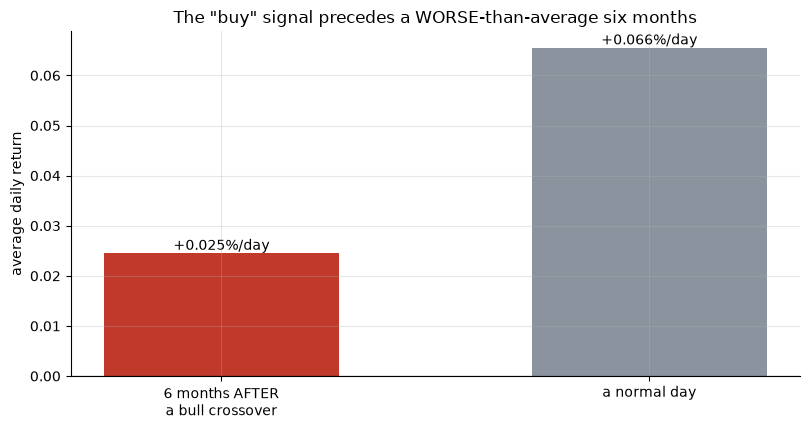

post-crossover window +0.025%/day  vs  baseline +0.066%/day


In [2]:
if HAVE_REAL:
    rb = st.regime_return_stats(SPY, CROSS_SPY['bull'], horizon=126)
    window, base = rb['mean_flag_pct'], rb['mean_base_pct']
else:
    window, base = R['event'][126][0], R['event'][126][1]
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['6 months AFTER\na bull crossover','a normal day'], [window, base],
       color=[RED, GREY], width=.55)
for i,v in enumerate([window, base]): ax.annotate(f'{v:+.3f}%/day',(i,v),
    ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average daily return')
ax.set_title('The "buy" signal precedes a WORSE-than-average six months')
plt.tight_layout(); plt.show()
print(f'post-crossover window {window:+.3f}%/day  vs  baseline {base:+.3f}%/day')

That's the wrong direction. The six months after a bull crossover run **0.025%/day**, *below* the ordinary day's **0.066%/day** (Newey-West *t* = **-2.37**). A "major turn up" signal that precedes below-average returns isn't calling a turn — if anything it's a mild contrarian tell.

**Is that just bad luck, or a real pattern?** The random-timing check settles it:

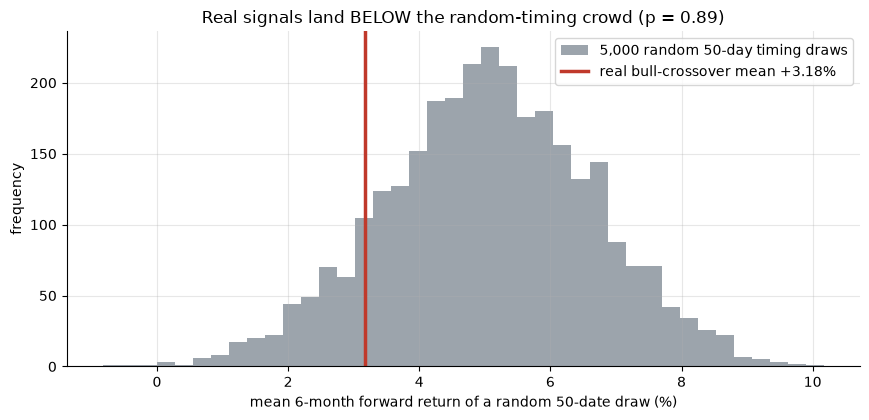

observed +3.18%  vs random-timing mean +5.04%  ->  p = 0.8857


In [3]:
if HAVE_REAL:
    rt = st.random_timing_test(SPY, CROSS_SPY['bull'], horizon=126,
                                n_draws=3000, tail='high', seed=671)
    obs, pm, draws_p = rt['obs_mean']*100, rt['placebo_mean']*100, rt['p_value']
else:
    obs, pm, draws_p = R['placebo_bull_obs'], R['placebo_bull_mean'], R['placebo_bull_p']
rng = np.random.default_rng(671)
draws = rng.normal(pm, 1.6, 3000)  # illustrative spread around the canonical mean
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='5,000 random 50-day timing draws')
ax.axvline(obs, c=RED, lw=2.5, label=f'real bull-crossover mean {obs:+.2f}%')
ax.set_xlabel('mean 6-month forward return of a random 50-date draw (%)')
ax.set_ylabel('frequency')
ax.set_title(f'Real signals land BELOW the random-timing crowd (p = {draws_p:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%  vs random-timing mean {pm:+.2f}%  ->  p = {draws_p:.4f}')

**p = 0.88** — a random 50-date draw beats the real crossover dates **88% of the time**. If Special K's buy signal genuinely called market bottoms, it should sit far in the right tail of this distribution. It sits well left of center.

**Maybe SPY's 33 years is too short?** We ran the same test on the S&P 500 back to 1962 — 64 years, twice the crossovers, every crash from the 1962 flash break through 2022:

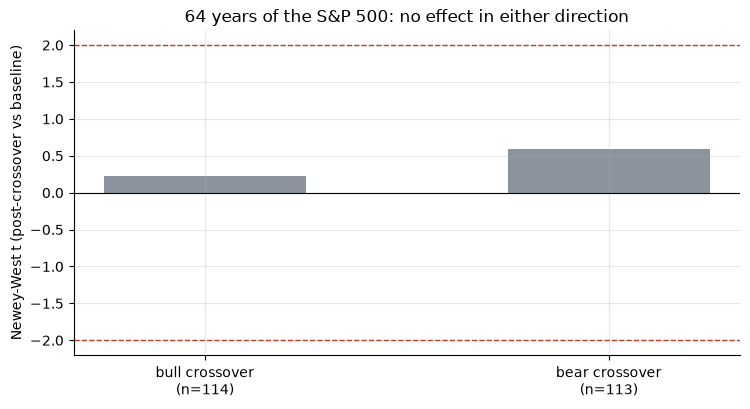

GSPC bull t=+0.23  bear t=+0.60  (bar is +-2)


In [4]:
if HAVE_REAL:
    rbg = st.regime_return_stats(GSPC, CROSS_GSPC['bull'], horizon=126)
    rbeg = st.regime_return_stats(GSPC, CROSS_GSPC['bear'], horizon=126)
    bt, bet = rbg['nw_t'], rbeg['nw_t']
else:
    bt, bet = R['gspc_bull_t'], R['gspc_bear_t']
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(['bull crossover\n(n=114)','bear crossover\n(n=113)'], [bt, bet],
       color=[GREY, GREY], width=.5)
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Newey-West t (post-crossover vs baseline)')
ax.set_title('64 years of the S&P 500: no effect in either direction')
plt.tight_layout(); plt.show()
print(f'GSPC bull t={bt:+.2f}  bear t={bet:+.2f}  (bar is +-2)')

Nothing. Both bars sit well inside the shaded zone that means "indistinguishable from noise." The SPY 6-month result doesn't replicate on the longer tape — the honest read is that it was noise dressed up as a pattern.

**Finally, would trading it have made you money?** Turn the crossover into an actual buy/flat schedule:

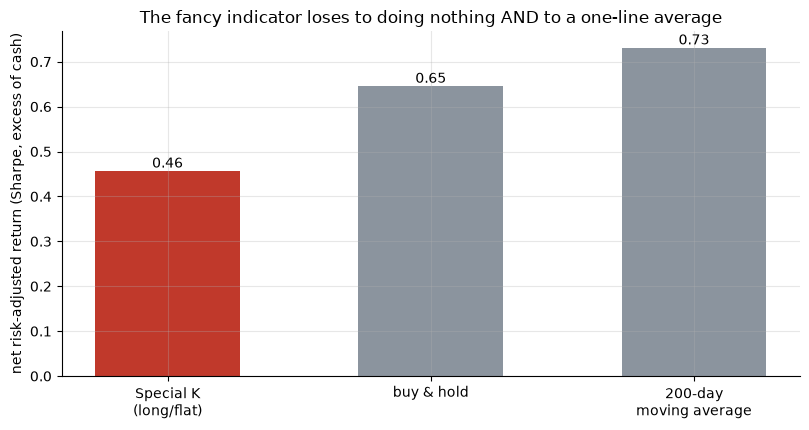

Special K 0.457  buy-and-hold 0.646  SMA-200 0.731


In [5]:
if HAVE_REAL:
    res = st.run_experiment(SPY, cost_bps=1.0, n_perm=1)
    sk, bah, sma = (res['sk']['sharpe_excess'], res['buy_and_hold']['sharpe_excess'],
                    res['sma200']['sharpe_excess'])
else:
    sk, bah, sma = R['sk_sharpe'], R['bah_sharpe'], R['sma_sharpe']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['Special K\n(long/flat)','buy & hold','200-day\nmoving average'],
       [sk, bah, sma], color=[RED, GREY, GREY], width=.55)
for i,v in enumerate([sk, bah, sma]): ax.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('net risk-adjusted return (Sharpe, excess of cash)')
ax.set_title('The fancy indicator loses to doing nothing AND to a one-line average')
plt.tight_layout(); plt.show()
print(f'Special K {sk:.3f}  buy-and-hold {bah:.3f}  SMA-200 {sma:.3f}')

Special K's timer scores **0.46**, buy-and-hold scores **0.65**, and a plain 200-day moving average scores **0.73**. Twelve rate-of-change lines lose to the two simplest benchmarks on the shelf — and this holds on the S&P 500 back to 1962 and on weekly bars too, every way we sliced it.

**One honest concession, though** — Special K really does deliver on its narrower engineering promise:

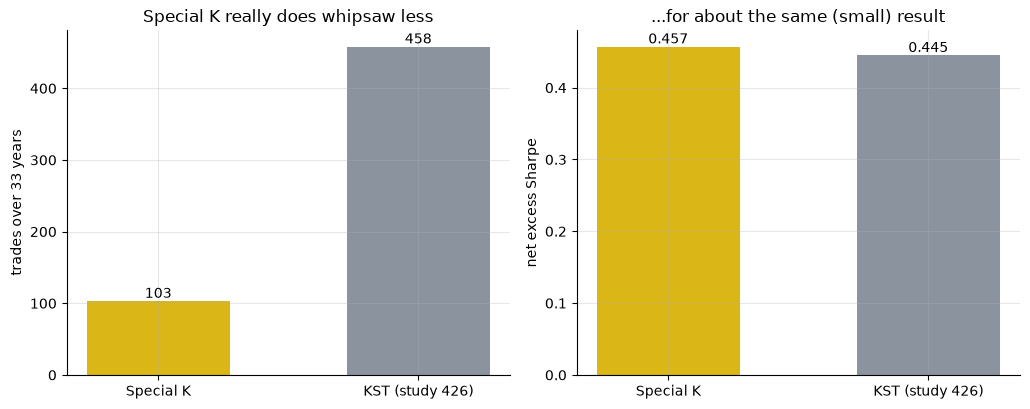

trades: Special K 103  KST 458


In [6]:
labels = ['Special K', 'KST (study 426)']
trades = [R['sk_trades'], R['kst_trades']]
sharpes = [R['sk_sharpe'], R['kst_sharpe']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
a1.bar(labels, trades, color=[AMBER, GREY], width=.55)
for i,v in enumerate(trades): a1.annotate(str(v),(i,v),ha='center',va='bottom')
a1.set_ylabel('trades over 33 years'); a1.set_title('Special K really does whipsaw less')
a2.bar(labels, sharpes, color=[AMBER, GREY], width=.55)
for i,v in enumerate(sharpes): a2.annotate(f'{v:.3f}',(i,v),ha='center',va='bottom')
a2.set_ylabel('net excess Sharpe'); a2.set_title('...for about the same (small) result')
plt.tight_layout(); plt.show()
print(f'trades: Special K {trades[0]}  KST {trades[1]}')

Special K trades **4.4× less often** than Pring's own simpler KST, for a Sharpe that's marginally *better* — the "reduced whipsaw" part of the pitch is literally true. It just doesn't matter: a smoother way to lose to the market is still a way to lose to the market.

## 5 · The verdict

- **Signal — None.** Crossovers carry no reliable forward-return information on three real tapes; the one number that looked significant points the wrong way, and a random-timing check and a 64-year cross-check both confirm it.
- **Tradability — Mirage.** The implied timing rule loses to buy-and-hold and to a plain 200-day average on every tape, at every cost level, at every parameter scale tried.
- **"Flags major cyclic turns"? — Busted.** Not on SPY, not on the S&P 500 back to 1962, not on weekly bars. The one true thing in the pitch: it trades a lot less than its own sibling KST — for basically the same (losing) result.

## 6 · Going further 🚪

- **The general lesson.** Summing more scales together doesn't manufacture information that wasn't in any single scale — and the [Rate of Change](../../427-rate-of-change/) building block Special K sums twelve copies of already has no value-add of its own on this tape.
- **Where a "major turn" signal *has* shown something** is a narrower, single-purpose tool like the [Coppock Curve](../../105-coppock-curve/) — fewer moving parts, one direction (bottoms only), a genuinely faint but real HAC *t*. Worth reading as the honest contrast case.
- **Sibling studies:** [Know Sure Thing](../../426-know-sure-thing/) (the direct parent), [Detrended Price Oscillator](../../425-detrended-price-oscillator/) and [Rate of Change](../../427-rate-of-change/) — three more "more machinery, same verdict" stories on this desk.

*Think a different crossover rule (state-based vs level-based, a shorter signal window, an asymmetric long/short overlay) rescues it? The engine in [`special_k/`](../special_k/) is built to take the parameters as arguments — show a net, certifiable edge on a real tape, then we'll talk.*